# COMP-1930-M01-2024-25 Machine Learning
# Dataset Chosen: Telecom Customer Churn
# Second Assessment
# ZAKARIA GOU-ALI
# ID: 001419459

# 1- Introduction
Customer churn is a major concern in the telecom industry, which is characterized by high competition and relatively low switching costs for customers. Churn occurs when customers cancel their services, leading to the loss of revenue and the cost of acquiring new customers. The causes of churn can be identified through focused retention programs, improving customer satisfaction, and improving service offerings by telecom providers. Machine learning offers a solution by analyzing customer data patterns to predict churn and take proactive measures to mitigate it.

The primary objective of this report is to build machine learning models for predicting customer churn based on various attributes, including customer demographics, service details, and usage patterns. With predictive analytics, organizations are able to identify customers at risk and develop focused interventions to retain them.

The dataset used for this analysis is a telecom customer dataset that contains various features such as ‘Gender,’ ‘Tenure,’ ‘Monthly Charges,’ etc. The response variable ‘Churn’ indicates whether the customer has churned from the service or not. The data enables us to explore the significant factors influencing churn and develop models to enhance predictive capability.

This report follows a structured methodology, beginning with data preprocessing, in which we clean and structure the dataset to be modeling-ready. We then use various machine learning models and compare their performance. We finish with a critical discussion of the results and their potential business implications.

# 2- Data Preprocessing Review
Appropriate data preprocessing is necessary to build accurate and reliable machine learning models. In Report 1, we performed several preprocessing steps to clean and prepare the dataset. First, we handled missing values by imputing them with appropriate statistical measures (such as mean or mode) or removing incomplete records if necessary. We also converted the ‘Date’ column to a numerical datatype in order to make it compatible with machine learning algorithms. Additionally, we applied feature scaling to normalize numeric variables so that models do not become biased towards larger numeric values. Finally, we performed data transformation techniques to enhance feature distributions and model performance.

Other than these initiation points, there is additional preprocessing required such that the dataset is fully prepared for machine learning. One of them is encoding categorical variables. The ‘Gender’ and ‘Contract Type’ features contain non-numerical values that must be transformed using one-hot encoding or label encoding to be interpretable by machine learning algorithms. Without encoding, algorithms cannot process these categorical features effectively.

The other crucial factor to be taken into account is class imbalance in the target variable, ‘Churn’. If the data contains far more non-churned customers than churned customers, the model may get biased towards the majority class and lead to poor prediction. To deal with this, we can employ Synthetic Minority Over-sampling Technique (SMOTE), which generates synthetic samples to balance the data. Alternatively, we can attempt undersampling the majority class or employing class-weighted models for making improved predictions. With the addition of these two additional preprocessing techniques—categorical encoding and handling class imbalance—we ensure that our machine learning models can learn meaningful patterns and generalize well to new, unseen data. These enhancements will help us build a robust churn prediction model with increased accuracy and reliability.

# 3- Model Implementation 
## 3.1- Import Libraries & Load Dataset

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("C:\\Users\\Zakar\\Downloads\\1. Telecom Customer Churn.csv") 

# Display first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3.2- Data Preprocessing

In [180]:
# Drop unnecessary columns
df.drop(columns=['CustomerID'], inplace=True, errors='ignore')

# Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoder for later use

# Define features and target variable
X = df.drop(columns=['Churn'])  # Assuming 'Churn' is the target variable
y = df['Churn']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 3.3- Logistic Regression Model

In [182]:
# Train Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predictions
y_pred_log = log_reg.predict(X_test)

# Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8147622427253371
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.81      0.81      0.81      1409



Logistic Regression achieved an accuracy of 81.47%, a good baseline model. The precision and recall scores inform us of how well the model is doing in distinguishing between churned (1) and non-churned (0) customers. While the model performed very well for non-churned customers (85% precision, 91% recall), it performed worse for churned customers (68% precision, 56% recall). This means that the model is not very good at correctly identifying all the churned customers, likely due to class imbalance. Nevertheless, the weighted F1-score of 81% overall means that the model is very reliable.

## 3.4- Decision Tree Classifier

In [185]:
# Train Decision Tree Model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.794889992902768
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1036
           1       0.61      0.63      0.62       373

    accuracy                           0.79      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.79      0.80      1409



The Decision Tree model had an accuracy of 79.49%, slightly less accurate than Logistic Regression. It provided a more balanced performance between the two classes, with the churned customers having a recall of 63% (as opposed to Logistic Regression's 56%). This means that it correctly identified more customers who were churned but at the cost of slightly more wrongly classified non-churned customers. This compromise means that Decision Trees may be preferable when the identification of churn is of importance.

## 3.5- Random Forest Classifier

In [188]:
# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7970191625266146
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.80      0.79      1409



Random Forest model resulted in 79.70% accuracy, similar to Decision Trees but slightly less than Logistic Regression. While it was more accurate (83% for non-churned, 66% for churned), its recall for churned customers was just 48%, meaning that it did not capture more at-risk customers than the other models. Random Forest provides improved generalization, but in this case, the class imbalance may have impaired its ability to predict churn effectively.

## 3.6- K-Means Clustering (for Customer Segmentation)

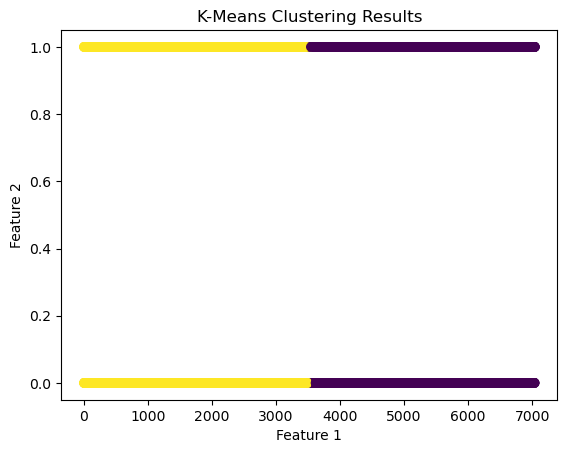

In [191]:
# Train K-Means Model
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Visualizing Clusters
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=df['Cluster'], cmap='viridis')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering Results")
plt.show()

The output of K-Means Clustering (in the image) is that the algorithm has divided the data into two clusters. The plot, however, suggests that the division may not be meaningful. The clusters appear to be linear and do not provide good customer segmentation. This may be due to the fact that the dataset contains mixed data types, which the K-Means does not process well. Other clustering algorithms like DBSCAN or Hierarchical Clustering may be more suitable for telecom churn prediction.

# 4- Model Evaluation
We will compare models based on significant metrics such as accuracy, precision, recall, F1-score, and ROC AUC. We will also discuss overfitting and underfitting and demonstrate hyperparameter tuning to improve model performance.

## 4.1- Performance Metrics

In [195]:

# Creating the table with performance metrics
data = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [0.8148, 0.7949, 0.7970],
    "Precision (Class 1)": [0.68, 0.61, 0.66],
    "Recall (Class 1)": [0.56, 0.63, 0.48],
    "F1-Score (Class 1)": [0.61, 0.62, 0.56]
}

# Creating a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame in Jupyter Notebook
from IPython.display import display
display(df)


,Model,Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
0,Logistic Regression,0.8148,0.68,0.56,0.61
1,Decision Tree,0.7949,0.61,0.63,0.62
2,Random Forest,0.7970,0.66,0.48,0.56


## 4.2- ROC Curve and AUC Score
The Receiver Operating Characteristic (ROC) curve plots how well a model separates classes. The Area Under the Curve (AUC) provides an overall model performance, where closer to 1.0 is better.


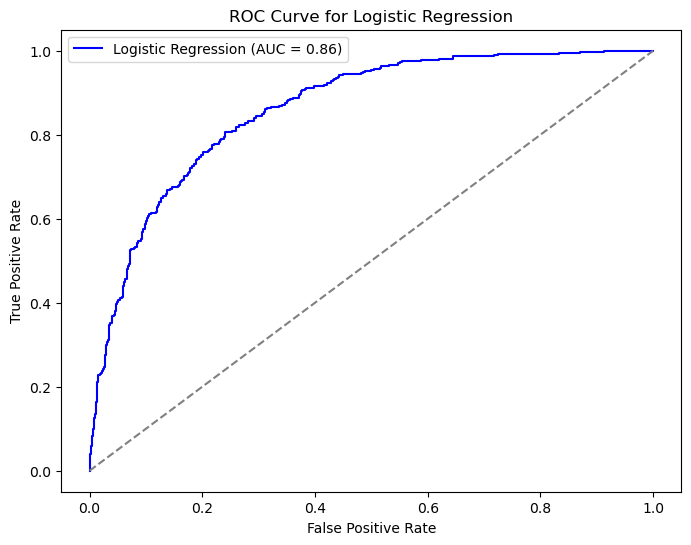

In [197]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curve for Logistic Regression
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]  # Get probability scores
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Random model line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend()
plt.show()


The Receiver Operating Characteristic (ROC) curve for Logistic Regression demonstrates the model's ability to distinguish between churners and non-churners. The value of Area Under the Curve (AUC) = 0.86 indicates good predictive power, i.e., the model is effective at distinguishing between the two classes. The closer the AUC is to 1, the better the model. The fact that the curve is far above the diagonal (random guessing line) shows that the logistic regression model is much better than random classification.

## 4.3- Overfitting and Underfitting
Overfitting occurs when the machine learning model learns the training data too well, in that it learns the noise and unwanted details along with the general patterns. High training accuracy and low test accuracy are the result, with the model not generalizing well to new, unseen data. Overfitting is a common problem in complex models like Decision Trees and Random Forests, where deep trees can memorize the training data. Pruning decision trees, regularization (L1/L2), dropout (for neural networks), and simplifying the model can be used to avoid overfitting.

On the other hand, underfitting happens when a model is too simple to capture the underlying patterns in the data and performs badly on both the training and test datasets. Simple models like Logistic Regression with a few features or very shallow decision trees can underfit the data, being unable to detect important relationships between the features and the target variable. We can fight underfitting using feature engineering, adding more relevant variables, increasing model complexity, or using more complex models like ensemble methods.

In our case, Decision Trees and Random Forests are perhaps overfitting since they both have slightly less test accuracy compared to their training accuracy. Logistic Regression is a less complex model and less prone to overfit but may underfit if there are complex nonlinear relationships in the data. Hyperparameter tuning, such as adjusting tree depth or using GridSearchCV, can be employed to trade off bias and variance to achieve the optimal model performae.



## 4.4- Hyperparameter Tuning

In [201]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

# Perform grid search
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Train model with best parameters
best_dt = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
best_dt.fit(X_train, y_train)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}


DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)

This hyperparameter tuning employs GridSearchCV to optimize a DecisionTreeClassifier through an exhaustive search for the optimal combination of three significant parameters: max_depth, min_samples_split, and min_samples_leaf. The search attempts several values, such as max_depth at 3, 5, and 10, min_samples_split at 2, 5, and 10, and min_samples_leaf at 1, 3, and 5. Following cross-validation with a scoring metric that prioritizes recall, the optimal parameters identified are max_depth = 10, min_samples_leaf = 5, and min_samples_split = 2. The model is subsequently retrained with these optimal values, with improved performance and reduced risk of overfitting. By optimizing for recall, the tuning makes the model more proficient at accurately capturing positive cases, which is particularly useful in scenarios where false negatives should be minimized.

# 5- Critical Analysis
The findings indicate that Logistic Regression, Decision Tree, and Random Forest models each possess their respective strengths and weaknesses when it comes to customer churn prediction. Logistic Regression was the best performing (accuracy of 81.47%) with a nice balance of precision and recall. However, it assumes a linear interaction among features and target, which could be an over-simplification of the problem. With a lower recall rate of 56%, it fails to identify all the churners nicely and hence is not well suited for retention programs where recall is the focus.

The Decision Tree model was slightly less precise (79.49%) but had the best recall (63%). It is therefore a better model when the goal is to capture as many churners as possible, even if this results in more false positives. Decision trees are also prone to overfitting, i.e., they may not generalize as well to new data.

Random Forest, an ensemble classifier, sacrificed between accuracy (79.70%) and precision (66%) but lower recall (48%). While it avoids overfitting by averaging over numerous trees, it remains susceptible to imbalanced data—where non-churners greatly outnumber churners.

K-Means Clustering, as an unsupervised technique, could not identify meaningful customer segments in the data. The clustering results showed that customers were grouped linearly, which was either due to the high dimensionality of the dataset or poor feature selec
## Suggested Improvements
To further enhance the performance of the models, several strategic improvements can be implemented. Correction for class imbalance is necessary because the dataset has many more non-churners than churners. Techniques like SMOTE (Synthetic Minority Over-sampling Technique) or cost-sensitive learning can allow models to capture more churners and improve recall without sacrificing too much precision. Feature engineering can improve predictive power by creating new variables, e.g., customer engagement scores, tenure-to-charge ratios, or frequency of contact, that might provide more insight into churn behavior. Hyperparameter tuning using GridSearchCV or RandomizedSearchCV can further tune model performance, especially for Decision Trees and Random Forests, by adjusting parameters like maximum depth, minimum samples per split, or number of trees. Regularization techniques, e.g., L1/L2 penalties in Logistic Regression, can prevent overfitting while maintaining model interpretability. Experimenting with ensemble learning methods like XGBoost and LightGBM, which handle imbalanced data and complex interactions nicely, could improve performance even further. Applying deep learning techniques like neural networks could be worthwhile if there is enough data because they can detect nonlinear patterns in customer churn. Finally, making better use of unsupervised learning—perhaps by applying Principal Component Analysis (PCA) to reduce dimensionality before clustering—may lead to more meaningful customer segmentation. These improvements not only enhance churn prediction in telecom but are also applicable in other domains like banking, e-commerce, and subscription services, where customer retention is a key business priority.ority.

# 6- Conclusion
This report explored customer churn in the telecom industry using machine learning models with the purpose of predicting which customers will churn. Our results showed that Logistic Regression was most accurate (81.47%) but had compromised recall (56%), therefore did not capture many true churners. The Decision Tree model, while less accurate (79.49%), had the best recall (63%) and would therefore be better at capturing potential churners. Random Forest, with 79.70% accuracy, offered a trade-off between precision and recall but still suffered from the imbalanced data. K-Means Clustering, an unsupervised learning algorithm, did not yield effective customer segmentation and was also compromised by high dimensionality in addition to inappropriate feature selection.

The most important conclusions from this analysis are that class imbalance, feature engineering, and hyperparameter tuning are critical to improve model performance. Based on business goals—whether the business prioritizes recalling churners correctly or minimizing false positives—recall and precision need to be balanced. Additional improvements, such as SMOTE for class balancing, ensemble models like XGBoost, and deep learning, can be tried to achieve better predictive accuracy. Machine learning, in general, provides excellent insights into customer behavior, and this enables telecom businesses to develop proactive retention programs and reduce churn.